# Multitag localization (likelihood)

Localize the tags of every experiment folder with the likelihood method in `../Localization/LikelyHoodLocalization.py` (Python version of `LikelyHoodLocalization.m`, no MATLAB needed). Results are directly comparable with `localization_sdp.ipynb`: same experiments, same anchors, same error metric. `lkhd_debugging.ipynb` shows every intermediate step for one experiment.

**Method.** For every tag, circles are drawn around each anchor with radius $\text{wrapped} + K\lambda$ for the estimated $K$, $K \pm 1$ and $K \pm 2$ (`CIRCLES` = 5; 3 keeps only $K \pm 1$, 7 adds $K \pm 3$). The image is blurred with a `BLUR_PX` disk and the brightest point is the tag estimate. After each round (up to `ROUNDS`) the most confident 10% of tags are promoted to anchors; when that is no tag (fewer than 10 left), the most confident one is tried and kept only if the other tags' mean confidence improves (`PROMOTE_BY = "conf"`; `None` = MATLAB rule only).

**Phase period.** The measured phase grows as $M \cdot \frac{2\pi f d}{c}$ with $M$ = `PHASE_MULT` = 2 (see `ML_ranging_multitag_SVR.ipynb`), so one step of $K$ is $\lambda = \frac{c}{2fM}$ = 8.2 cm at 915 MHz. Each link's radius is split into whole steps $K$ and the remainder, so the main circle's radius is exactly $\frac{c\,\phi}{2\pi f M} + K\frac{c}{2fM}$ = `dist_est_k_svr`.

For each experiment we localize from:
- **Ground truth**: circles at the true distance (`distances.csv`), showing the error of the method alone,
- **SVR+K 775-995** / **775-955**: `phase_main` and `k_est` from `distance_estimates.csv`,
- **Phase+K_gt 775-995** / **775-955**: `phase_main` with the ground-truth `k_gt` instead, showing how much the K errors cost (in the tables only, not plotted).

Each link's circle radius is averaged over its runs.

**Setup.** 2D (x, y) as in `localization_sdp.ipynb`, with the same `N_ANCHORS` anchors per experiment (largest-area convex polygon). Positions are shifted by `MARGIN` and converted to cm so that the image coordinates are positive.

**Parameters.** `N_ANCHORS`, `CIRCLES`, `SCALE` (3 px/cm), `BLUR_PX` (21 px), `CONF_RADIUS_CM` (150 cm), `ROUNDS`, `PROMOTE_BY` and `MARGIN` are the same as in `localization_merged.ipynb`, so its Likelihood results match this notebook. Localization error = Euclidean distance between estimated and true tag positions.

In [8]:
import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull

DATA_DIR = Path(".")
LOC_DIR = Path("../Localization").resolve()
sys.path.insert(0, str(LOC_DIR))
from LikelyHoodLocalization import Params, likelihood_localization

EXPERIMENTS = sorted((p.parent for p in DATA_DIR.glob("*/points.csv")), key=lambda p: int(p.name))
# Method -> (band, K column of distance_estimates.csv); None = ground-truth distances.csv
METHODS = {
    "Ground truth": None,
    "SVR+K 775-995": ("775-995", "k_est"),
    "SVR+K 775-955": ("775-955", "k_est"),
    "Phase+K_gt 775-995": ("775-995", "k_gt"),
    "Phase+K_gt 775-955": ("775-955", "k_gt"),
}
PLOT_METHODS = [m for m in METHODS if not m.startswith("Phase+K_gt")]  # K_gt runs are in the tables only
N_ANCHORS = 6

# Likelihood parameters: same as localization_merged.ipynb
C = 299792458.0
MAIN_FREQ = 915e6                        # Hz, same as MAIN_FREQ in ML_ranging_multitag_SVR.ipynb
PHASE_MULT = 2                           # same as PHASE_MULT in ML_ranging_multitag_SVR.ipynb
PERIOD = C / (2 * MAIN_FREQ * PHASE_MULT)  # m, distance per step of K
CIRCLES = 5                              # circles per anchor: K, K +- 1, K +- 2 (3 = K, K +- 1; 7 adds K +- 3)
SCALE = 3.0                              # image pixels per cm
BLUR_PX = 21                             # radius of the disk blur in pixels (MATLAB: fspecial('disk', 15))
CONF_RADIUS_CM = 150                     # black-out radius around the peak for the confidence
ROUNDS = 5                               # max rounds (MATLAB: 5)
PROMOTE_BY = "conf"                      # when the 10% rule promotes no tag: try one, keep it if confidence improves; None = off
MARGIN = 0.5                             # m, empty border around the tags in the image
print([p.name for p in EXPERIMENTS], f"PERIOD = {PERIOD * 100:.2f} cm")

['1', '2', '3', '4', '5', '6', '7', '8', '9'] PERIOD = 8.19 cm


## Solver
`likelihood_localization` works in cm on the shifted positions; each radius is split into whole steps K and the remainder (`wrapped`).

In [9]:
def pick_anchors(pts, n=N_ANCHORS):
    # The n tags whose convex hull has the largest area (indices into pts, 0-based); same as localization_sdp.ipynb.
    return np.array(max(itertools.combinations(range(len(pts)), n), key=lambda s: ConvexHull(pts[list(s)]).volume))


def load_radii(exp, method):
    # NxN circle radius (m) per link (tag number = index + 1), averaged over runs; unmeasured links are 0.
    D_gt = np.loadtxt(exp / "distances.csv", delimiter=",", ndmin=2)
    if METHODS[method] is None:
        return D_gt
    band, k_col = METHODS[method]
    est = pd.read_csv(exp / "distance_estimates.csv")
    est = est[est["band (MHz)"] == band]
    radius = C * est["phase_main"] / (2 * np.pi * MAIN_FREQ * PHASE_MULT) + est[k_col] * PERIOD
    radius = radius.groupby([est["tagA_num"], est["tagB_num"]]).mean()
    R = np.zeros_like(D_gt)
    for (a, b), r in radius.items():
        R[a - 1, b - 1] = R[b - 1, a - 1] = r
    return R


def localize(R, pts, anchors):
    # R: NxN circle radii (m), pts: N x 2 true positions (m). Returns errors (m) and estimates (m) for the non-anchor tags.
    tags = np.setdiff1d(np.arange(len(pts)), anchors)
    K = np.floor(R / PERIOD)
    wrapped = R - K * PERIOD

    offset = pts.min(axis=0) - MARGIN
    P = (pts - offset) * 100  # cm, inside [0, lim]
    params = Params(lam=PERIOD * 100, lim=np.ceil(P.max() + MARGIN * 100), scale=SCALE, circles=CIRCLES,
                    blur_px=BLUR_PX, conf_radius=CONF_RADIUS_CM, rounds=ROUNDS, promote_by=PROMOTE_BY)
    estimates, _ = likelihood_localization(wrapped * 100, K, R != 0, anchors, P[anchors], tags, params, verbose=False)

    est = np.array([estimates[t] for t in tags]) / 100 + offset
    return np.linalg.norm(est - pts[tags], axis=1), tags, est

## Localize every experiment

In [10]:
rows, results = [], {}
for exp in EXPERIMENTS:
    pts = pd.read_csv(exp / "points.csv")[["x", "y"]].to_numpy()
    anchors = pick_anchors(pts)
    for method in METHODS:
        err, tags, est = localize(load_radii(exp, method), pts, anchors)
        results[exp.name, method] = (pts, anchors, tags, est, err)
        rows += [{"experiment": int(exp.name), "method": method, "tag": t + 1, "error (cm)": e * 100}
                 for t, e in zip(tags, err)]
    print(f"experiment {exp.name}: anchors = tags {sorted((anchors + 1).tolist())}")
errors = pd.DataFrame(rows)

experiment 1: anchors = tags [3, 5, 6, 7, 10, 11]
experiment 2: anchors = tags [2, 5, 6, 7, 10, 11]
experiment 3: anchors = tags [1, 2, 7, 10, 11, 12]
experiment 4: anchors = tags [1, 2, 7, 10, 11, 12]
experiment 5: anchors = tags [1, 5, 7, 8, 10, 11]
experiment 6: anchors = tags [1, 4, 7, 8, 10, 11]
experiment 7: anchors = tags [2, 4, 6, 7, 8, 11]
experiment 8: anchors = tags [1, 2, 4, 6, 7, 11]
experiment 9: anchors = tags [2, 4, 5, 6, 7, 11]


## Localization error per experiment (cm)

In [11]:
def summary(e):
    return pd.Series({"mean": e.mean(), "median": e.median(), "p90": e.quantile(0.9), "max": e.max()})


per_exp = errors.groupby(["experiment", "method"], sort=False)["error (cm)"].apply(summary).unstack().round(1)
overall = errors.groupby("method", sort=False)["error (cm)"].apply(summary).unstack().round(1)
overall.index = pd.MultiIndex.from_product([["All"], overall.index])
pd.concat([per_exp, overall])

mean  median   p90    max
    method                                       
1   Ground truth         4.9     4.6   6.2    7.4
    SVR+K 775-995       12.5    10.0  25.0   29.7
    SVR+K 775-955       17.4    13.4  29.2   32.4
    Phase+K_gt 775-995   5.1     4.5   8.8   11.4
    Phase+K_gt 775-955   6.7     5.6  11.8   12.6
2   Ground truth         5.5     4.9   7.2    7.5
    SVR+K 775-995       13.3    12.1  19.8   23.5
    SVR+K 775-955       21.3    16.3  40.8   49.2
    Phase+K_gt 775-995   4.1     4.1   6.8    7.8
    Phase+K_gt 775-955   4.6     4.5   7.0    7.5
3   Ground truth         7.4     5.2  13.2   14.4
    SVR+K 775-995       18.3    16.3  28.9   32.2
    SVR+K 775-955       14.1    14.7  20.5   20.7
    Phase+K_gt 775-995   3.7     3.3   6.5    8.3
    Phase+K_gt 775-955   3.4     3.3   5.4    5.6
4   Ground truth         6.8     4.8  11.7   12.2
    SVR+K 775-995       12.9    11.1  19.7   23.3
    SVR+K 775-955       13.1    11.0  19.9   27.6
    Phase+K_gt 775-995   3.7     3.8   6.2    7.2
    Phase+K_gt 775-955   5.2     5.3   6.8    7.8
5   Ground truth         8.1     6.9  13.5   13.5
    SVR+K 775-995       13.4    10.0  23.8   32.2
    SVR+K 775-955       15.5    15.7  17.1   18.3
    Phase+K_gt 775-995   9.2     8.7  15.1   15.4
    Phase+K_gt 775-955   6.2     5.1  11.2   13.1
6   Ground truth         6.2     5.8   9.4   12.6
    SVR+K 775-995       13.6     8.6  24.8   40.3
    SVR+K 775-955       15.8    14.1  26.9   34.5
    Phase+K_gt 775-995   4.5     4.3   6.7    7.1
    Phase+K_gt 775-955   3.6     3.7   4.9    5.1
7   Ground truth         6.0     4.8   9.0   11.4
    SVR+K 775-995       11.4    10.5  19.8   23.0
    SVR+K 775-955        8.9     7.3  16.5   20.7
    Phase+K_gt 775-995   2.4     2.2   3.8    4.6
    Phase+K_gt 775-955   3.6     3.1   6.1    7.5
8   Ground truth         5.5     3.9   9.3   11.8
    SVR+K 775-995        9.7    10.1  16.4   18.5
    SVR+K 775-955       12.7     6.5  28.2   47.1
    Phase+K_gt 775-995   6.3     4.7  11.9   16.3
    Phase+K_gt 775-955   6.2     4.7  11.8   16.3
9   Ground truth         7.0     6.2  10.6   14.0
    SVR+K 775-995        9.0     7.2  14.2   14.3
    SVR+K 775-955       33.2    12.7  82.6  142.7
    Phase+K_gt 775-995   6.2     6.2   8.1    9.5
    Phase+K_gt 775-955   4.0     3.8   6.1    6.8
All Ground truth         6.4     4.9  12.1   14.4
    SVR+K 775-995       12.7    10.2  23.5   40.3
    SVR+K 775-955       16.9    12.2  30.9  142.7
    Phase+K_gt 775-995   5.0     4.4   9.2   16.3
    Phase+K_gt 775-955   4.8     4.0   7.7   16.3

In [12]:
# Mean error per experiment, one column per method (cm)
errors.pivot_table(index="experiment", columns="method", values="error (cm)", aggfunc="mean", sort=False).round(1)

method,Ground truth,SVR+K 775-995,SVR+K 775-955,Phase+K_gt 775-995,Phase+K_gt 775-955
experiment,,,,,
1,4.9,12.5,17.4,5.1,6.7
2,5.5,13.3,21.3,4.1,4.6
3,7.4,18.3,14.1,3.7,3.4
4,6.8,12.9,13.1,3.7,5.2
5,8.1,13.4,15.5,9.2,6.2
6,6.2,13.6,15.8,4.5,3.6
7,6.0,11.4,8.9,2.4,3.6
8,5.5,9.7,12.7,6.3,6.2
9,7.0,9.0,33.2,6.2,4.0


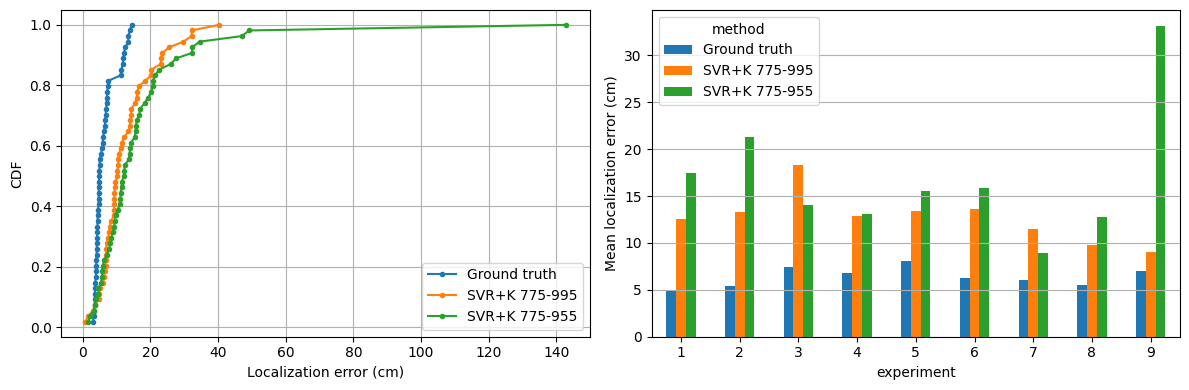

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for method in PLOT_METHODS:
    e = np.sort(errors.loc[errors.method == method, "error (cm)"])
    axs[0].plot(e, np.arange(1, len(e) + 1) / len(e), ".-", label=method)
axs[0].set_xlabel("Localization error (cm)"); axs[0].set_ylabel("CDF"); axs[0].grid(); axs[0].legend()

means = errors[errors.method.isin(PLOT_METHODS)].pivot_table(index="experiment", columns="method", values="error (cm)", aggfunc="mean", sort=False)
means.plot.bar(ax=axs[1], rot=0)
axs[1].set_ylabel("Mean localization error (cm)"); axs[1].grid(axis="y")
plt.tight_layout(); plt.show()

## Estimated vs true positions

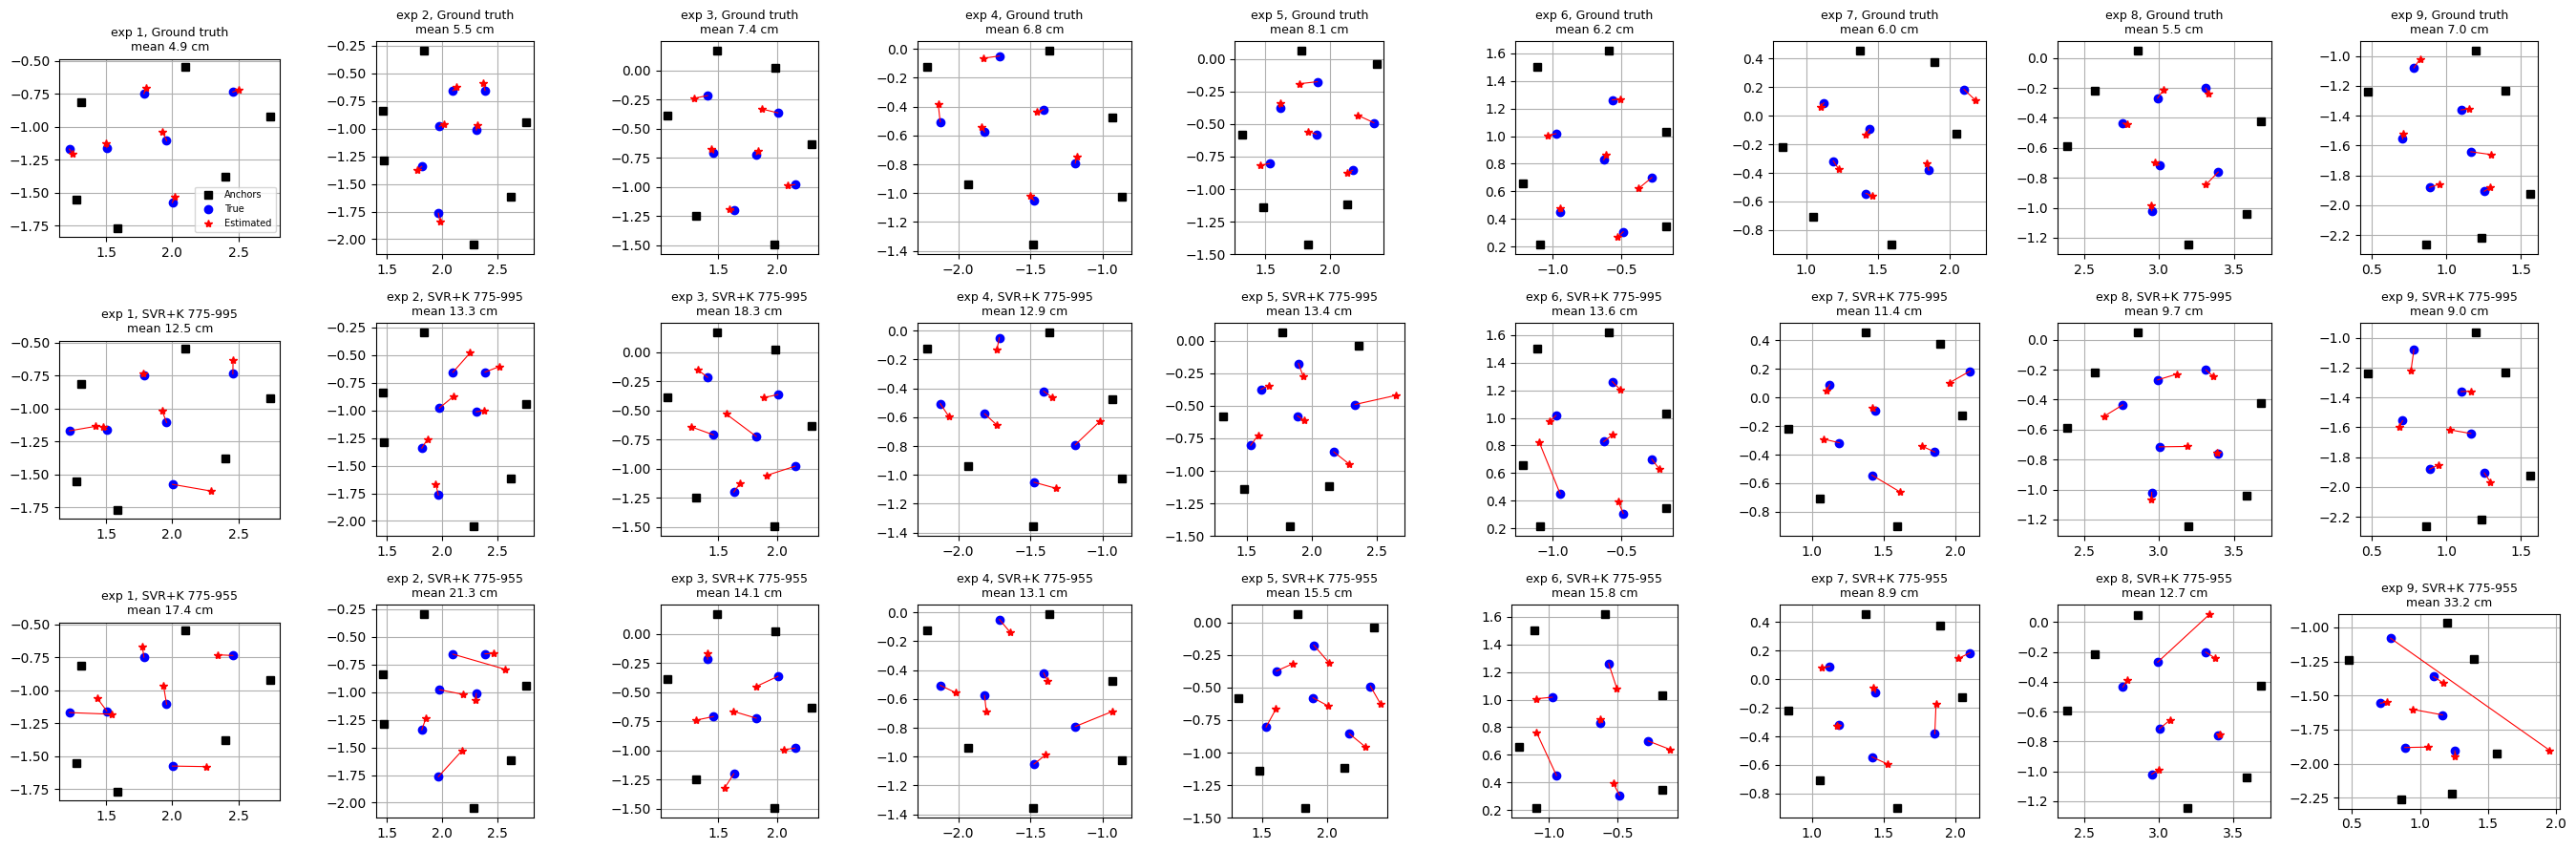

In [14]:
fig, axs = plt.subplots(len(PLOT_METHODS), len(EXPERIMENTS), figsize=(3 * len(EXPERIMENTS), 3 * len(PLOT_METHODS)), squeeze=False)
for c, exp in enumerate(EXPERIMENTS):
    for r, method in enumerate(PLOT_METHODS):
        pts, anchors, tags, est, err = results[exp.name, method]
        ax = axs[r, c]
        ax.plot(*pts[anchors].T, "ks", label="Anchors")
        ax.plot(*pts[tags].T, "bo", label="True")
        ax.plot(*est.T, "r*", label="Estimated")
        for t, e in zip(pts[tags], est):
            ax.plot([t[0], e[0]], [t[1], e[1]], "r-", lw=0.8)
        ax.set_aspect("equal"); ax.grid()
        ax.set_title(f"exp {exp.name}, {method}\nmean {err.mean() * 100:.1f} cm", fontsize=9)
axs[0, 0].legend(fontsize=7)
plt.tight_layout(); plt.show()